# **바이크 임대 데이터 분할 검정 실습**

In [1]:
!pip install koreanize_matplotlib  # 한글폰트 설치
import koreanize_matplotlib

import pandas as pd; import numpy as np
import matplotlib.pyplot as plt; import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input
import warnings; warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 57.7 MB/s eta 0:00:00


In [2]:
df=pd.read_csv("바이크_임대.csv", encoding="cp949")
df

,월,시간대,기온,습도,풍속,자외선,강우량,강설량,임대_건수
0,01월,1시,-3.2,40,0.5,0.0,0.0,0.0,90
1,01월,2시,-3.3,41,0.7,0.0,0.0,0.0,54
2,01월,3시,-3.7,42,0.9,0.0,0.0,0.0,41
3,01월,4시,-4.0,44,1.0,0.0,0.0,0.0,43
4,01월,5시,-4.2,53,1.1,0.0,0.0,0.0,73
...,...,...,...,...,...,...,...,...,...
8755,12월,20시,0.0,31,2.2,0.0,0.0,0.0,142
8756,12월,21시,-1.0,32,0.9,0.0,0.0,0.0,144
8757,12월,22시,-1.6,35,1.0,0.0,0.0,0.0,131
8758,12월,23시,-2.1,36,1.7,0.0,0.0,0.0,107


In [3]:
y=df["임대_건수"]
X=df.drop(["임대_건수"], axis=1)
X.head()

,월,시간대,기온,습도,풍속,자외선,강우량,강설량
0,01월,1시,-3.2,40,0.5,0.0,0.0,0.0
1,01월,2시,-3.3,41,0.7,0.0,0.0,0.0
2,01월,3시,-3.7,42,0.9,0.0,0.0,0.0
3,01월,4시,-4.0,44,1.0,0.0,0.0,0.0
4,01월,5시,-4.2,53,1.1,0.0,0.0,0.0


In [4]:
X_oh=pd.get_dummies(X,columns=['월', '시간대']).astype(int)
X_oh.shape

(8760, 42)

In [5]:
X_oh

,기온,습도,풍속,자외선,강우량,강설량,월_01월,월_02월,월_03월,월_04월,...,시간대_23시,시간대_24시,시간대_2시,시간대_3시,시간대_4시,시간대_5시,시간대_6시,시간대_7시,시간대_8시,시간대_9시
0,-3,40,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,-3,41,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,-3,42,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,-4,44,1,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,-4,53,1,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,0,31,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8756,-1,32,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8757,-1,35,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8758,-2,36,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


### 인공 신경망 모델 설정하기

In [6]:
# 랜덤 시드 고정
SEED=42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 훈련/검증 데이터 나누기
x_train, x_test, y_train, y_test = train_test_split(X_oh, y, test_size=0.3, random_state=SEED)
print("훈련용 피처", x_train.shape)
print("검증용 피처", x_test.shape)
print("훈련용 타깃", y_train.shape)
print("검증용 타깃", y_test.shape)

# 모델 설정
model=Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4,  activation='relu'),
    Dense(1)    ])
model.compile(optimizer="adam", loss="mse")

from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(
    monitor='val_loss',          # 검증 손실을 모니터링
    patience=5,                  # 5번 연속 개선되지 않으면 멈춤
    restore_best_weights=True )  # val_loss가 가장 낮은 모델로 파라미터 복원

hist=model.fit(x_train, y_train, epochs=300, validation_data=(x_test, y_test),
                 callbacks=[early_stop])

훈련용 피처 (6132, 42)
검증용 피처 (2628, 42)
훈련용 타깃 (6132,)
검증용 타깃 (2628,)
Epoch 1/300
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 6811.0293 - val_loss: 3006.8750
Epoch 2/300
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2842.1240 - val_loss: 2597.7588
Epoch 3/300
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2401.5273 - val_loss: 2180.5884
Epoch 4/300
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1915.2622 - val_loss: 1673.5784
Epoch 5/300
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1454.6029 - val_loss: 1225.2383
Epoch 6/300
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1000.7396 - val_loss: 757.8505
Epoch 7/300
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 576.2322 - val_loss: 386.7487
Epoch 8/300
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 276.9971 - val_loss: 186.7999
Epoch 9/300
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 162.1466 - val_loss: 136.2228
Epoch 10/300
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 124.7512 - val_loss: 115.5457
Epoch 11/30

### 학습된 모델의 성능 평가하기

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


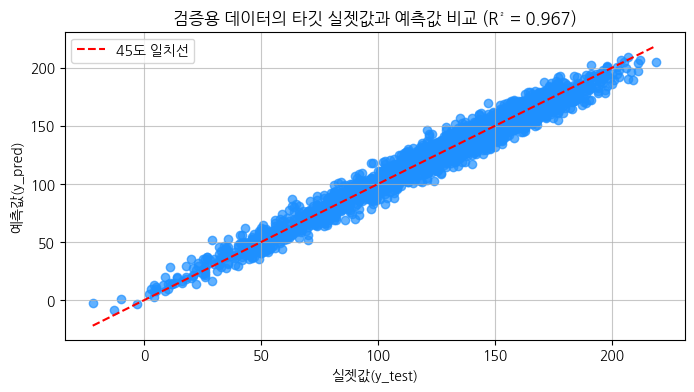

In [7]:
# R 제곱 계산
y_pred=model.predict(x_test)
r2=r2_score(y_test, y_pred)

# 예측값과 실제값 비교
plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred, color='dodgerblue', alpha=0.7)  # alpha는 투명도 설정 (0~1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='45도 일치선')
plt.title(f'검증용 데이터의 타깃 실젯값과 예측값 비교 (R² = {r2:.3f})')
plt.xlabel('실젯값(y_test)')
plt.ylabel('예측값(y_pred)')
plt.legend(); plt.grid(alpha=0.7); plt.show()